### Load libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Goal of the project
This project aims to develop a machine learning system that recommends the most suitable crop to grow and predicts crop yield based on environmental factors, including weather, rainfall, and climate.

### Questions
* What type of crop grows best under different conditions like soil, humidity,
weather?
* Which crops are tolerant of very low or very high pH levels?
* What element corresponds to the specific type of crops?

### Load the data

In [3]:
df = pd.read_csv('data/Crop_recommendation.csv')

In [4]:
print(df.head())

    N   P   K  temperature   humidity        ph    rainfall label
0  90  42  43    20.879744  82.002744  6.502985  202.935536  rice
1  85  58  41    21.770462  80.319644  7.038096  226.655537  rice
2  60  55  44    23.004459  82.320763  7.840207  263.964248  rice
3  74  35  40    26.491096  80.158363  6.980401  242.864034  rice
4  78  42  42    20.130175  81.604873  7.628473  262.717340  rice


### Explore the data

In [7]:
# Check the data shape and some information of it
print(df.shape)
print(df.info())
print(df.describe())

(2200, 8)
<class 'pandas.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   str    
dtypes: float64(4), int64(3), str(1)
memory usage: 137.6 KB
None
                 N            P            K  temperature     humidity  \
count  2200.000000  2200.000000  2200.000000  2200.000000  2200.000000   
mean     50.551818    53.362727    48.149091    25.616244    71.481779   
std      36.917334    32.985883    50.647931     5.063749    22.263812   
min       0.000000     5.000000     5.000000     8.825675    14.258040   
25%      21.000000    28.000000    20.00

### Missing values

In [8]:
# Count the number of missing values in the data
print(df.isnull().sum())

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64


### Imbalanceness

In [25]:
# Count the number of unique crops
print("The number of crops:", df['label'].unique().size)
print(df['label'].value_counts())

The number of crops: 22
label
rice           100
maize          100
chickpea       100
kidneybeans    100
pigeonpeas     100
mothbeans      100
mungbean       100
blackgram      100
lentil         100
pomegranate    100
banana         100
mango          100
grapes         100
watermelon     100
muskmelon      100
apple          100
orange         100
papaya         100
coconut        100
cotton         100
jute           100
coffee         100
Name: count, dtype: int64


### Correlation matrix

In [ ]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
print(num_cols)

Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall'], dtype='str')


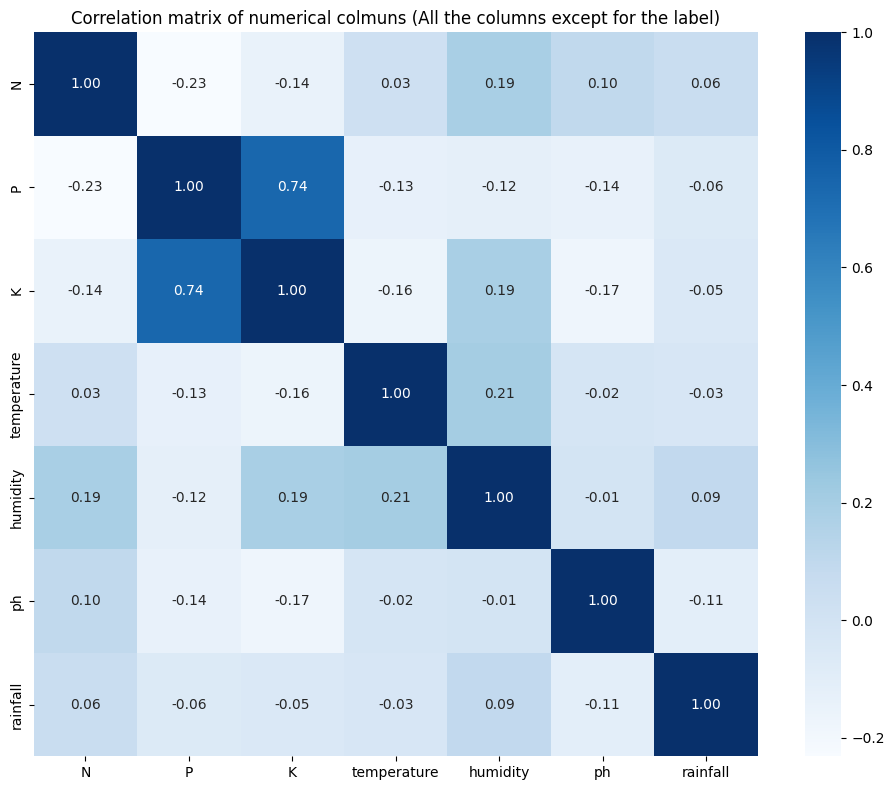

In [36]:
# Make a correlation matrix
cm = df[num_cols].corr()

# Plot it
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='.2f',
    ax=ax,
    square=True
)
ax.set_title("Correlation matrix of numerical colmuns (All the columns except for the label)")
plt.tight_layout()
plt.show()

K and p are strongly correlated with each other. There can't be seen other strong correlations.

### Outliers

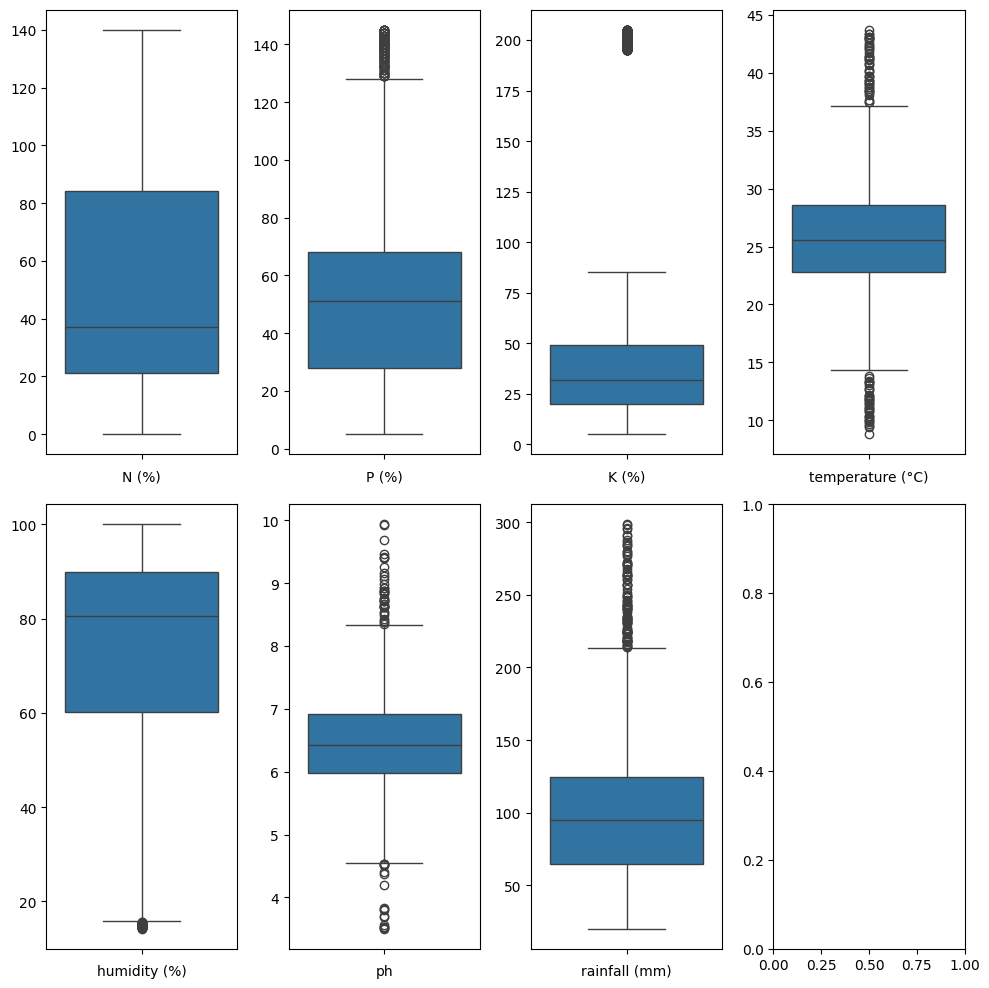

In [60]:
fig, ax = plt.subplots(2, 4, figsize=(10,10), sharex=False)

ax = ax.flatten()

for ax, col in zip(ax, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    if col == 'N' or col == 'P' or col == 'K' or col == 'humidity':
        ax.set_xlabel(f"{col} (%)")
    elif col == 'temperature':
        ax.set_xlabel(f"{col} (°C)")
    elif col == 'rainfall':
        ax.set_xlabel(f"{col} (mm)")
    else:
        ax.set_xlabel(col)
    
        
    ax.set_ylabel("")

#for ax in ax[len(num_cols):]:
    #ax.set_visible(False)

plt.tight_layout()
plt.show()

All variables except N have outliers, we need to discuss how to handle those.

In [ ]:
fig, ax = plt.subplots(2, 4, figsize=(10,10), sharex=False)

ax = ax.flatten()

for ax, col in zip(ax, num_cols):
    sns.boxplot(y=df[col], ax=ax)
    if col == 'N' or col == 'P' or col == 'K' or col == 'humidity':
        ax.set_xlabel(f"{col} (%)")
    elif col == 'temperature':
        ax.set_xlabel(f"{col} (°C)")
    elif col == 'rainfall':
        ax.set_xlabel(f"{col} (mm)")
    else:
        ax.set_xlabel(col)
    
        
    ax.set_ylabel("")

#for ax in ax[len(num_cols):]:
    #ax.set_visible(False)

plt.tight_layout()
plt.show()